# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [1]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 14:53:40.664913: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 14:53:40.988172: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 14:53:40.988219: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 14:53:40.990344: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 14:53:41.171755: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 14:53:41.174440: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 4. Load the Data


In [22]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(root_dir + "/train/X_train.txt")
    y_train = np.loadtxt(root_dir + "/train/y_train.txt")
    X_test = np.loadtxt(root_dir + "/test/X_test.txt")
    y_test = np.loadtxt(root_dir + "/test/y_test.txt")
    #print(X_train.shape)

    y_train = y_train.astype(int) - 1
    y_test  = y_test.astype(int) - 1
    
    #raise NotImplementedError("Complete the data-loading function.")
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

#print(X_train[0])
class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]


# TODO: define num_features and num_classes

num_features = X_train.shape[1]        # number of columns in X
num_classes  = len(np.unique(y_train)) # number of distinct labels


## 5. Quick Inspection


In [3]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [4]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
    inputs = keras.layers.Input(shape=(input_dim,), name="features")
    
    x = keras.layers.Dense(256, activation="relu", name="dense_1")(inputs)
    x = keras.layers.Dense(128, activation="relu", name="dense_2")(x)
    x = keras.layers.Dense(64, activation="relu", name="dense_3")(x)
    output = keras.layers.Dense(num_classes, activation="softmax", name="dense_4")(x)
    
    # Build the Keras Model object
    model = keras.Model(inputs=inputs, outputs=output, name="baseline_dnn")

    
    # Compile with Adam lr=1e-3, sparse categorical cross-entropy, accuracy
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-04-23 14:54:10.203010: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-23 14:54:10.203778: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 561)]             0         
                                                                 
 dense_1 (Dense)             (None, 256)               143872    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


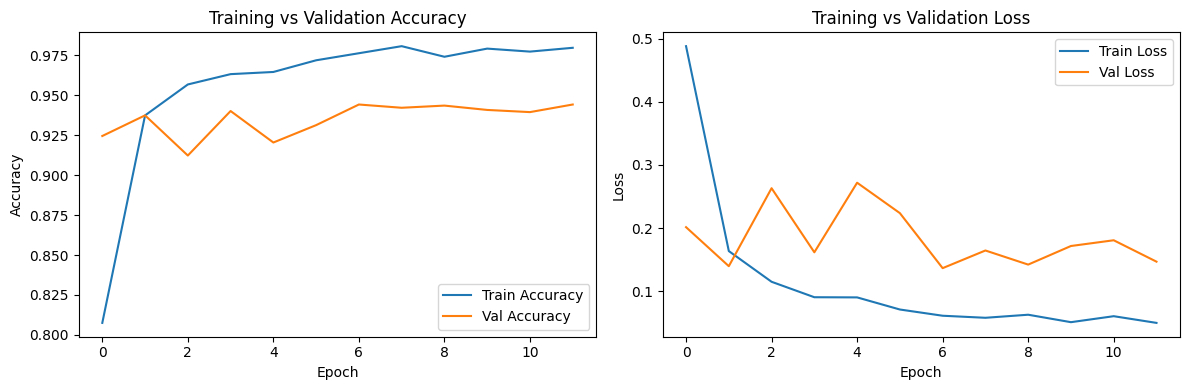

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 1ms/step
Baseline test accuracy: 0.9243

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.90      0.99      0.95       496
  WALKING_UPSTAIRS       0.88      0.93      0.91       471
WALKING_DOWNSTAIRS       0.99      0.82      0.90       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



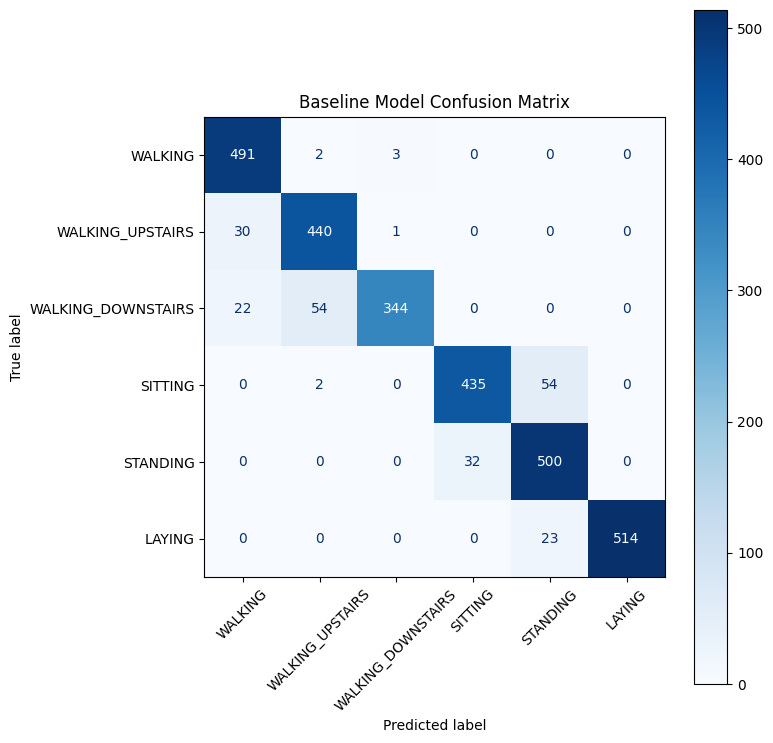

In [7]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
test_acc = accuracy_score(y_test, y_pred)

print(f"Baseline test accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Baseline Model Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [8]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(min(300, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            if input_details["dtype"] == np.int8:
                x = np.clip(np.round(x), -128, 127).astype(np.int8)
            else:
                x = np.clip(np.round(x), 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [9]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

tflite_results = []

fp32_model = convert_to_tflite_fp32(baseline_model)
fp32_size = save_binary_model(fp32_model, "baseline_fp32.tflite")
fp32_acc, _ = evaluate_tflite_model(fp32_model, X_test, y_test)
tflite_results.append(["FP32", fp32_size, fp32_acc])

dynamic_model = convert_to_tflite_dynamic_range(baseline_model)
dynamic_size = save_binary_model(dynamic_model, "baseline_dynamic.tflite")
dynamic_acc, _ = evaluate_tflite_model(dynamic_model, X_test, y_test)
tflite_results.append(["Dynamic Range", dynamic_size, dynamic_acc])

float16_model = convert_to_tflite_float16(baseline_model)
float16_size = save_binary_model(float16_model, "baseline_float16.tflite")
float16_acc, _ = evaluate_tflite_model(float16_model, X_test, y_test)
tflite_results.append(["Float16", float16_size, float16_acc])

int8_model = convert_to_tflite_int8(baseline_model)
int8_size = save_binary_model(int8_model, "baseline_int8.tflite")
int8_acc, _ = evaluate_tflite_model(int8_model, X_test, y_test)
tflite_results.append(["INT8", int8_size, int8_acc])

results_df = pd.DataFrame(tflite_results, columns=["Model", "Size (KB)", "Test Accuracy"])
print("\nTFLite conversion results:")
print(results_df)


INFO:tensorflow:Assets written to: /tmp/tmpnycsplul/assets


INFO:tensorflow:Assets written to: /tmp/tmpnycsplul/assets
2026-04-23 15:25:59.927224: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:25:59.927285: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:25:59.928147: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnycsplul
2026-04-23 15:25:59.928998: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:25:59.929011: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpnycsplul
2026-04-23 15:25:59.933847: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 15:25:59.934680: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:25:59.977398: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmped8gfp2j/assets


INFO:tensorflow:Assets written to: /tmp/tmped8gfp2j/assets
2026-04-23 15:26:00.823837: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:26:00.823910: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:26:00.824152: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmped8gfp2j
2026-04-23 15:26:00.825065: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:26:00.825079: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmped8gfp2j
2026-04-23 15:26:00.828514: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:26:00.872390: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmped8gfp2j
2026-04-23 15:26:00.885308: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpkb2c5zzg/assets


INFO:tensorflow:Assets written to: /tmp/tmpkb2c5zzg/assets
2026-04-23 15:26:01.620020: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:26:01.620088: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:26:01.620294: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkb2c5zzg
2026-04-23 15:26:01.621879: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:26:01.621900: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkb2c5zzg
2026-04-23 15:26:01.625878: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:26:01.670166: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkb2c5zzg
2026-04-23 15:26:01.681333: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpgd12r4wt/assets


INFO:tensorflow:Assets written to: /tmp/tmpgd12r4wt/assets



TFLite conversion results:
           Model   Size (KB)  Test Accuracy
0           FP32  726.753906       0.924330
1  Dynamic Range  186.148438       0.924330
2        Float16  365.777344       0.924330
3           INT8  185.359375       0.923651


/home/pedleyhuang/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 15:26:02.621813: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:26:02.621878: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:26:02.622137: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgd12r4wt
2026-04-23 15:26:02.623048: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:26:02.623064: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgd12r4wt
2026-04-23 15:26:02.625224: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:26:02.666031: I tensorflow/cc/saved_model/

## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

comparison_df = pd.DataFrame([
    # Baseline Model from earlier
    {"Model Family": "Baseline DNN", "Format": "Keras FP32", "Test Accuracy": test_acc, "Model Size (KB)": None},
    {"Model Family": "Baseline DNN", "Format": "TFLite FP32", "Test Accuracy": fp32_acc, "Model Size (KB)": fp32_size},
    {"Model Family": "Baseline DNN", "Format": "TFLite Dynamic Range", "Test Accuracy": dynamic_acc, "Model Size (KB)": dynamic_size},
    {"Model Family": "Baseline DNN", "Format": "TFLite Float16", "Test Accuracy": float16_acc, "Model Size (KB)": float16_size},
    {"Model Family": "Baseline DNN", "Format": "TFLite INT8", "Test Accuracy": int8_acc, "Model Size (KB)": int8_size},
])

print(comparison_df)


   Model Family                Format  Test Accuracy  Model Size (KB)
0  Baseline DNN            Keras FP32       0.924330              NaN
1  Baseline DNN           TFLite FP32       0.924330       726.753906
2  Baseline DNN  TFLite Dynamic Range       0.924330       186.148438
3  Baseline DNN        TFLite Float16       0.924330       365.777344
4  Baseline DNN           TFLite INT8       0.923651       185.359375


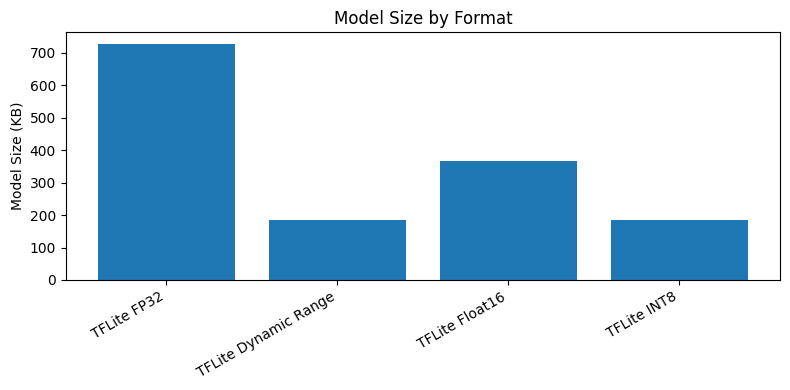

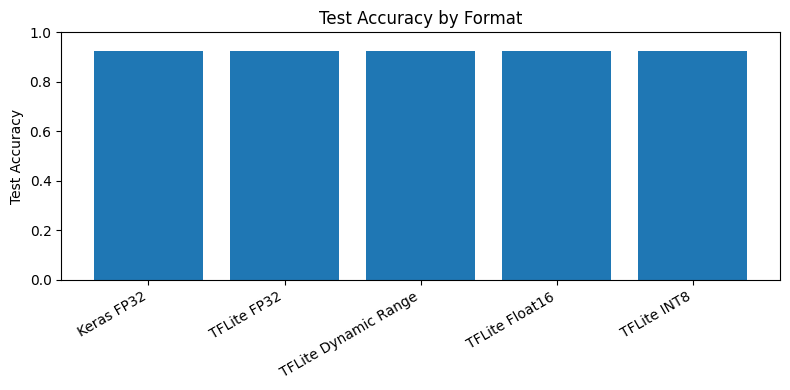

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# Bar plot: model size
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Model Size by Format")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Bar plot: test accuracy
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy by Format")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.0)  # since accuracy is between 0 and 1
plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


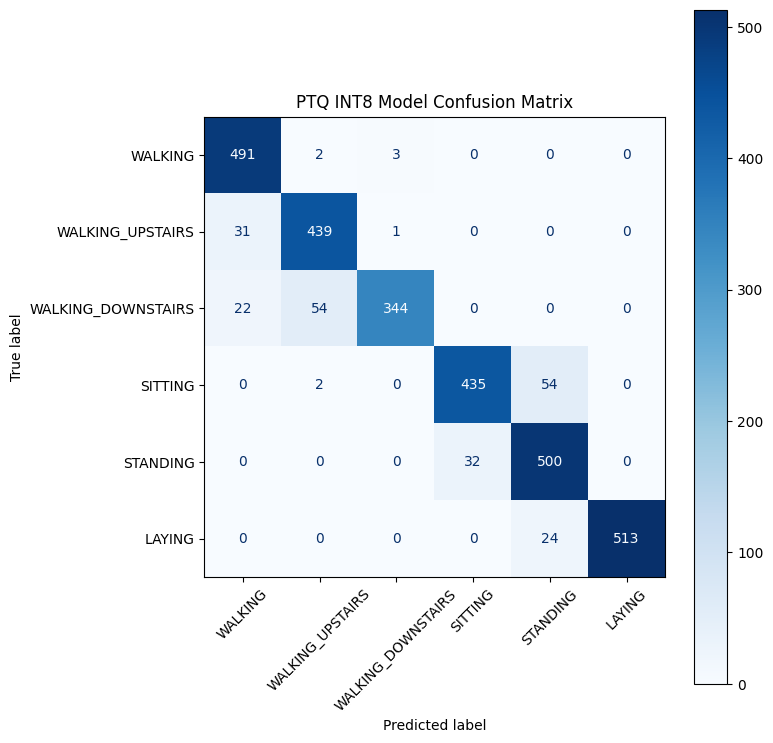

Classification report for PTQ INT8 model:
                    precision    recall  f1-score   support

           WALKING       0.90      0.99      0.94       496
  WALKING_UPSTAIRS       0.88      0.93      0.91       471
WALKING_DOWNSTAIRS       0.99      0.82      0.90       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [15]:
int8_acc, int8_y_pred = evaluate_tflite_model(int8_model, X_test, y_test)
cm_int8 = confusion_matrix(y_test, int8_y_pred)

disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp_int8.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("PTQ INT8 Model Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification report for PTQ INT8 model:")
print(classification_report(y_test, int8_y_pred, target_names=class_names))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [16]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# Create QAT model from trained baseline model
quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)

# Compile QAT model
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)
qat_model.summary()


Model: "baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_1 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 64)                8261      
 pperV2)                                              

### Fine-Tune the QAT Model


In [17]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)


Epoch 1/8
92/92 [==============================] - 2s 9ms/step - loss: 0.0494 - accuracy: 0.9845 - val_loss: 0.1247 - val_accuracy: 0.9456
Epoch 2/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0393 - accuracy: 0.9864 - val_loss: 0.1268 - val_accuracy: 0.9463
Epoch 3/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0385 - accuracy: 0.9871 - val_loss: 0.1364 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0351 - accuracy: 0.9879 - val_loss: 0.1259 - val_accuracy: 0.9463
Epoch 5/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0339 - accuracy: 0.9891 - val_loss: 0.1655 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0337 - accuracy: 0.9883 - val_loss: 0.1487 - val_accuracy: 0.9497
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0340 - accuracy: 0.9881 - val_loss: 0.1310 - val_accuracy: 0.9490
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [18]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probs = qat_model.predict(X_test)
qat_pred = np.argmax(qat_probs, axis=1)

qat_test_acc = accuracy_score(y_test, qat_pred)
print(f"QAT Keras model test accuracy: {qat_test_acc:.4f}")

print("QAT Keras model classification report:")
print(classification_report(y_test, qat_pred, target_names=class_names))


93/93 [==============================] - 0s 3ms/step
QAT Keras model test accuracy: 0.9359
QAT Keras model classification report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.96      0.95      0.95       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.84      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [19]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# Convert QAT model to fully int8 TFLite
qat_int8_tflite = convert_to_tflite_int8(qat_model)

# Save and measure size
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")

# Evaluate on test set
qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)
print(f"QAT INT8 TFLite test accuracy: {qat_int8_acc:.4f}")


INFO:tensorflow:Assets written to: /tmp/tmpdz_f0fed/assets


INFO:tensorflow:Assets written to: /tmp/tmpdz_f0fed/assets


QAT INT8 TFLite test accuracy: 0.9359


/home/pedleyhuang/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 15:36:43.784847: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 15:36:43.784901: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 15:36:43.785072: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdz_f0fed
2026-04-23 15:36:43.786580: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 15:36:43.786594: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpdz_f0fed
2026-04-23 15:36:43.793012: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 15:36:43.856142: I tensorflow/cc/saved_model/

## 12. PTQ Int8 vs QAT Int8


In [20]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

ptq_vs_qat_df = pd.DataFrame([
    {"Model": "PTQ INT8", "Test Accuracy": int8_acc, "Model Size (KB)": int8_size},
    {"Model": "QAT INT8", "Test Accuracy": qat_int8_acc, "Model Size (KB)": qat_int8_size_kb},
])
print(ptq_vs_qat_df)


      Model  Test Accuracy  Model Size (KB)
0  PTQ INT8       0.923651       185.359375
1  QAT INT8       0.935867       185.773438


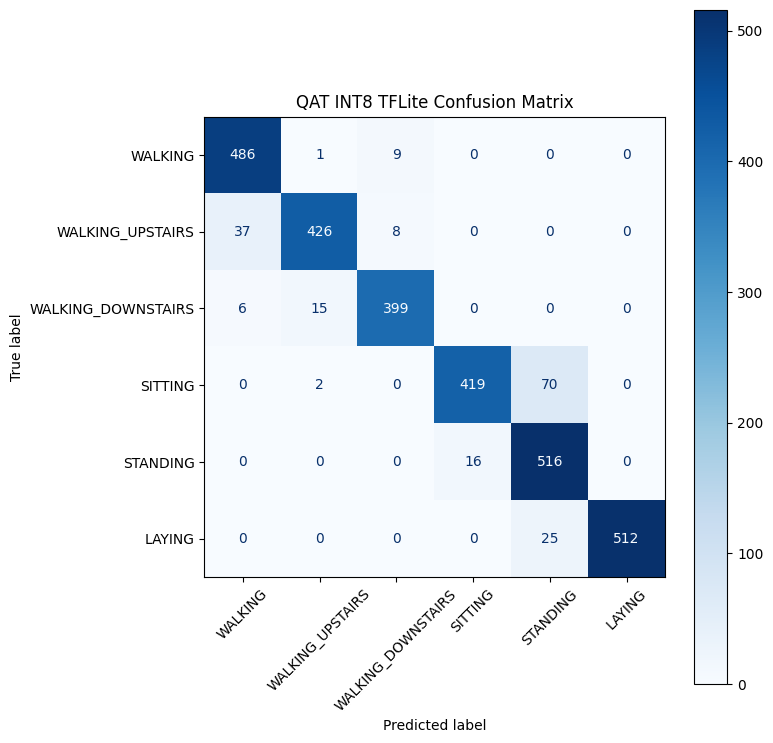

In [21]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

cm_qat_int8 = confusion_matrix(y_test, qat_int8_pred)

disp_qat_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8,
                                       display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp_qat_int8.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("QAT INT8 TFLite Confusion Matrix")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
